# Notebook: Sklearn Pipelines & Feature Engineering

---

### Why this matters
Raw data is never model-ready. Before any algorithm sees your data, you need to:
- Scale numbers (so a $1M salary doesn't dominate a 0-1 age-normalized feature)
- Encode categories (ML models only speak numbers)
- Select the features that actually matter (noise features hurt accuracy)
- Chain all this reproducibly so train/test never leak information into each other

Pipelines solve all of this. They're the difference between notebook code that works once and production code that works always.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold, RFE
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score

np.random.seed(42)
sns.set_theme(style='whitegrid')

## 1. The Problem Without a Pipeline

The most common beginner mistake in ML is fitting preprocessors on the **entire dataset** before splitting. This is called **data leakage** — your model has seen information from the test set during training, so your evaluation metrics are optimistic (fake).

```
BAD (leaky):                    GOOD (no leakage):
scaler.fit(ALL data)            X_train, X_test = split(data)
↓                               scaler.fit(X_train only)   ← fit on train
X_scaled = scaler.transform()   X_train_s = scaler.transform(X_train)
↓                               X_test_s  = scaler.transform(X_test)  ← apply only
train_test_split()              
```

A Pipeline enforces the correct order automatically — it only fits on training data and applies to test data.

## Fit on Train, Transform on Both

When we say **"fit on train, apply to test"**, it means:

- **fit** = learn statistics *from the data* (e.g. mean, std)
- **transform** = apply those learned statistics to rescale data

---

### What `fit()` Does

`scaler.fit(X_train)` scans the training data and memorizes key numbers. Nothing changes yet.

```python
X_train['age'] = [22, 35, 48, 19, 61, ...]
scaler.fit(X_train)
# scaler now remembers: mean = 37, std = 15
```

### What `transform()` Does

`scaler.transform(X)` uses those memorized numbers to rescale.

```python
scaled = (x - 37) / 15    # uses mean/std learned during fit()
```

---

### The Rule

```python
scaler.fit(X_train)                      # learn mean/std from training data only
X_train_scaled = scaler.transform(X_train)   # apply it to train
X_test_scaled  = scaler.transform(X_test)    # apply THE SAME mean/std to test
```

---

### Why Never Fit on Test Data?

**Problem 1 — Inconsistent scaling**  
If you `fit(X_test)`, the scaler learns a *different* mean/std from the test set.
Now train and test are on different scales — the model was trained on one scale and evaluated on another.

**Problem 2 — Data leakage**  
If you `fit(all data)` before splitting, the scaler has already "seen" test samples when computing the mean. Information from the future leaked into training. Your test score will look better than real-world performance actually is.

---

### Pipeline Enforces This Automatically

```python
pipeline.fit(X_train)       # fit() called on every step using ONLY X_train
pipeline.predict(X_test)    # transform() called using already-fitted params
```

No risk of accidentally fitting on test data.

---

In [2]:
# Load breast cancer dataset (classification: malignant vs benign)
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Class balance — Train: {y_train.mean():.2%} benign | Test: {y_test.mean():.2%} benign")

Train: (455, 30) | Test: (114, 30)
Class balance — Train: 62.64% benign | Test: 63.16% benign


## 2. The Pipeline Class

A `Pipeline` is a list of `(name, transform)` steps where each step's output becomes the next step's input. The last step can be an estimator (model).

```python
Pipeline(steps=[
    ('step1', SomeTransformer()),
    ('step2', AnotherTransformer()),
    ('model', SomeEstimator()),   # optional — only if you want to include the model
])
```

**Key rules:**
- All steps except the last must implement `fit_transform()`
- `pipeline.fit(X_train)` calls `fit_transform` on every step in order
- `pipeline.transform(X_test)` calls `transform` only (no fitting)
- Data leakage is structurally impossible

In [3]:
# Simplest possible pipeline: scale → classify
simple_pipe = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000))
])

simple_pipe.fit(X_train, y_train)
acc = simple_pipe.score(X_test, y_test)
print(f"Simple pipeline accuracy: {acc:.4f}")
print()
print("Pipeline steps:")
for name, step in simple_pipe.steps:
    print(f"  {name}: {type(step).__name__}")

Simple pipeline accuracy: 0.9825

Pipeline steps:
  scaler: StandardScaler
  model: LogisticRegression


## 3. Scaling — Why It Matters and Which to Use

Most ML algorithms (especially distance-based and gradient-based ones) are sensitive to feature scale. A feature ranging 0–100,000 will dominate a feature ranging 0–1 unless you scale.  

Gradient-based = algorithms that learn by minimizing a loss function using gradients.

A gradient is just the slope of the loss curve — it tells the algorithm "move your weights in this direction to reduce error."

| Scaler | Formula | Best for | Breaks on |
|--------|---------|----------|----------|
| **StandardScaler** | `(x - mean) / std` | Normally distributed features | Outliers — they distort mean/std |
| **MinMaxScaler** | `(x - min) / (max - min)` | Neural networks, pixel values | Outliers — they compress everything else |
| **RobustScaler** | `(x - median) / IQR` | Data with outliers | Assumes symmetric distribution |

> **Rule of thumb:** Start with StandardScaler. Switch to RobustScaler when you have outliers you can't remove.

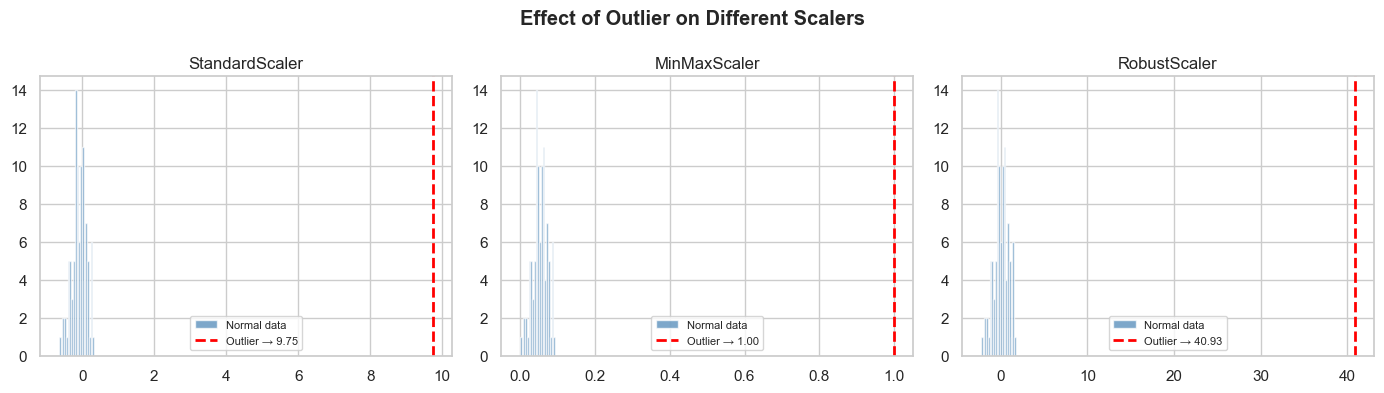

Outlier value after scaling:
  StandardScaler      :     9.75
  MinMaxScaler        :     1.00
  RobustScaler        :    40.93

RobustScaler compresses the outlier least — the normal data retains more spread.


In [4]:
# Inject an outlier to show the difference
feature = np.append(np.random.normal(50, 10, 99), 500)  # 99 normal + 1 extreme outlier

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler':   MinMaxScaler(),
    'RobustScaler':   RobustScaler(),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, scaler) in zip(axes, scalers.items()):
    scaled = scaler.fit_transform(feature.reshape(-1, 1)).flatten()
    ax.hist(scaled[:-1], bins=20, color='steelblue', alpha=0.7, label='Normal data')
    ax.axvline(scaled[-1], color='red', linestyle='--', linewidth=2, label=f'Outlier → {scaled[-1]:.2f}')
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.suptitle('Effect of Outlier on Different Scalers', fontweight='bold')
plt.tight_layout()
plt.show()

print("Outlier value after scaling:")
for name, scaler in scalers.items():
    scaled = scaler.fit_transform(feature.reshape(-1, 1)).flatten()
    print(f"  {name:<20}: {scaled[-1]:>8.2f}")
print("\nRobustScaler compresses the outlier least — the normal data retains more spread.")

## Encoding Categorical Features

ML models require numbers — categories must be converted before training.

---

### Why Encoding Matters

A model cannot interpret `"Red"`, `"Medium"`, or `"New York"` directly.
Every categorical feature must be mapped to a numeric representation.
The choice of encoder matters — a wrong choice can introduce false relationships or bloat your feature space.

---

### OneHotEncoder

Creates a separate binary column for each category. Exactly one column is `1`, the rest are `0`.

```
color = ["Red", "Blue", "Green"]

color_Red  color_Blue  color_Green
    1           0           0       ← Red
    0           1           0       ← Blue
    0           0           1       ← Green
```

**Use when:** Categories have no natural order — color, city, gender, payment method.

**Watch out for:**
- **Curse of dimensionality** — a feature with 500 unique cities creates 500 new columns
- **Dummy variable trap** — always drop one column (`drop='first'`) when not using regularization, since the dropped column is perfectly predictable from the others
- For high cardinality (many unique values), prefer Target Encoding instead

---

### OrdinalEncoder

Maps each category to an integer based on a defined order.

```
size = ["Small", "Medium", "Large"]
     →    0         1         2
```

**Use when:** Categories have a real, meaningful order — size, satisfaction level, education level, star ratings.

**Watch out for:**
- This implies **magnitude** — the model will treat `Large (2)` as twice `Medium (1)`
- If you use it on nominal data (e.g., color), you're introducing a false numeric relationship
- Always define the order explicitly — don't rely on alphabetical defaults

```python
OrdinalEncoder(categories=[["Small", "Medium", "Large"]])
```

---

### Target Encoding

Replaces each category with the **mean of the target variable** for that category.

```
city        avg_price (target mean)
New York  →   850,000
Austin    →   420,000
Detroit   →   210,000
```

**Use when:** A feature has high cardinality (100+ unique values) where OneHotEncoder would create too many columns.

**Watch out for:**
- **Data leakage** — if you compute target means using the full dataset before splitting, test labels influence training. Always fit inside a pipeline with cross-validation
- **Overfitting on rare categories** — a city with 2 rows will have an unstable mean. Use smoothing or a minimum sample threshold

---

### What About LabelEncoder?

> ⚠️ **Never use `LabelEncoder` on input features.**

`LabelEncoder` assigns arbitrary integers to categories:

```
Red   → 0
Blue  → 1
Green → 2
```

This implies **Green > Blue > Red**, which is meaningless. The model will treat it as a real numeric relationship.

`LabelEncoder` is only appropriate for encoding the **target variable `y`** in classification tasks, not for input features.

---


In [5]:
# Build a synthetic mixed dataset: numeric + categorical
df = pd.DataFrame({
    'age':       np.random.randint(18, 70, 200),
    'salary':    np.random.lognormal(10.5, 0.5, 200),
    'city':      np.random.choice(['NYC', 'LA', 'Chicago', 'Austin'], 200),      # nominal - categories with no order
    'seniority': np.random.choice(['junior', 'mid', 'senior', 'lead'], 200),     # ordinal - with meaningful order
    'churn':     np.random.randint(0, 2, 200)
})

print("Dataset preview:")
print(df.head(4))
print(f"\nShape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")

Dataset preview:
   age        salary     city seniority  churn
0   26  32296.250966       LA    junior      1
1   54  40760.830458      NYC      lead      1
2   50  24234.476676  Chicago       mid      0
3   68  61618.150336      NYC    senior      0

Shape: (200, 5)

Dtypes:
age            int64
salary       float64
city             str
seniority        str
churn          int64
dtype: object


## Sparse Matrix

A sparse matrix only stores the **non-zero values** instead of every cell.

---

### The Memory Problem

OneHotEncoding a `country` column with 200 unique countries across 10,000 rows:

```
Regular matrix:  10,000 rows × 200 columns = 2,000,000 values stored
                 but 1,990,000 of them are just 0

Sparse matrix:   only stores the 10,000 ones (one 1 per row)
                 everything else is assumed 0
```

Regular matrix wastes **99.5% of its memory** on zeros. Sparse matrix skips them entirely.

---

### What It Looks Like

```python
# Dense (regular) matrix:
[[0, 0, 1, 0],
 [0, 1, 0, 0],
 [1, 0, 0, 0]]

# Sparse matrix stores the exact same data as:
# "row 0, col 2 → 1"
# "row 1, col 1 → 1"
# "row 2, col 0 → 1"
# (all other positions assumed to be 0)
```

---

### In Practice

```python
# sparse_output=False  → returns a regular numpy array (easier to work with)
# sparse_output=True   → returns a sparse matrix (memory-efficient for large datasets)

OneHotEncoder(sparse_output=False)  # use for small/medium datasets
OneHotEncoder(sparse_output=True)   # use when you have hundreds of categories
```

> Most sklearn models accept sparse matrices directly — you don't always need to convert back to dense. Use `sparse_output=False` only when downstream steps (like pandas DataFrames) don't support sparse format.

In [6]:
# setting up x and y
X = df.drop('churn', axis=1)   # everything except the target column
y = df['churn']                 # just the target column (what we're predicting)

# defining which columns belong to which group
numeric_features   = ['age', 'salary']        # need scaling
nominal_features   = ['city']                 # need one-hot encoding
ordinal_features   = ['seniority']            # need ordinal encoding
ordinal_categories = [['junior', 'mid', 'senior', 'lead']]
# ↑ tells OrdinalEncoder the correct order — one list per ordinal column
# if you had 2 ordinal columns it would be [['a','b','c'], ['x','y','z']]

# building 3 mini pipelines - one per feature type
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # fill missing values with median
    ('scaler',  StandardScaler())                   # then scale
])
# order matters — impute first, then scale (can't scale NaN values)

nominal_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    # handle_unknown='ignore' → if test data has a city not seen in training,
    #                           don't crash — just encode it as all zeros
    # sparse_output=False     → return a regular numpy array, not a sparse matrix
])

ordinal_transformer = Pipeline(steps=[
    ('encoder', OrdinalEncoder(categories=ordinal_categories))
    # junior→0, mid→1, senior→2, lead→3
    # you must pass categories= otherwise it assigns numbers alphabetically
    # which would give: junior=1, lead=2, mid=3, senior=0 — wrong order
])

# combining all 3 into one columnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    # apply numeric_transformer to ['age', 'salary']
    ('nom', nominal_transformer, nominal_features),
    # apply nominal_transformer to ['city']
    ('ord', ordinal_transformer, ordinal_features),
    # apply ordinal_transformer to ['seniority']
])
# columns not mentioned here are DROPPED by default


full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),   # step 1: transform all columns
    ('model', LogisticRegression(max_iter=500))  # step 2: train the model
    # max_iter=500 → how many times the optimizer is allowed to iterate
    #               default is 100, sometimes not enough to converge
])

# train and evaluate
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

full_pipeline.fit(X_train, y_train)
# internally does:
#   preprocessor.fit_transform(X_train) → transformed X_train
#   LogisticRegression(transformed X_train, y_train)

full_pipeline.score(X_test, y_test)
# internally does:
#   preprocessor.transform(X_test)  ← uses params from fit from X_train, NOT re-fitting
#   LogisticRegression.predict(transformed X_test) → compare to y_test


# Inspect what the preprocessor produced
X_transformed = preprocessor.fit_transform(X_train)
# this is just to peek at the output — not part of the pipeline
# calling fit_transform again here is fine for inspection
print(f"Original shape: {X_train.shape}")
# (160, 4) → 160 rows, 4 columns: age, salary, city, seniority

print(f"After encoding: {X_transformed.shape}")
# (160, 7) → city exploded from 1 column into 4 (NYC, LA, Chicago, Austin)
#             age(1) + salary(1) + city(4) + seniority(1) = 7

ohe_cols = preprocessor.named_transformers_['nom']['encoder'].get_feature_names_out(['city'])
# named_transformers_['nom']  → access the 'nom' transformer (the nominal one)
# ['encoder']                 → access the OneHotEncoder step inside it
# .get_feature_names_out()    → returns ['city_Austin', 'city_Chicago', 'city_LA', 'city_NYC']

all_cols = numeric_features + list(ohe_cols) + ordinal_features
# manually reconstruct the column names in the order ColumnTransformer outputs them:
# ['age', 'salary', 'city_Austin', 'city_Chicago', 'city_LA', 'city_NYC', 'seniority']


Original shape: (160, 4)
After encoding: (160, 7)


## Feature Selection — Keep What Matters, Drop the Rest

More features ≠ better model. Irrelevant features add noise, slow training, and hurt interpretability.

---

### VarianceThreshold

If a feature barely changes across rows, it can't help the model learn anything.

```
has_email = [1, 1, 1, 1, 1, 1, 1, 0, 1, 1]  # almost always 1 — useless
age       = [22, 45, 31, 58, 27, ...]         # varies a lot — useful
```

`VarianceThreshold` removes features whose variance falls below a set threshold.
Use it as a quick first pass before anything else.

---

### SelectKBest

Tests each feature *individually* against the target and keeps the top K.

- Uses a statistical score (e.g. ANOVA F-score for regression, mutual info for classification)
- Fast and simple — good for a quick shortlist
- Limitation: tests features one at a time, so it misses combinations that are only useful *together*

---

### RFE (Recursive Feature Elimination)

Trains a model, ranks features by importance, drops the weakest one, retrains — repeats until K features remain.

```
Start: 20 features
Round 1: train → drop weakest → 19 features
Round 2: train → drop weakest → 18 features
...
Stop at K features
```

Slower than SelectKBest but smarter — the model itself decides what's useful.

---

### Feature Importance (Tree Models)

After training a tree-based model (Random Forest, XGBoost), you get a built-in importance score for every feature — no extra steps needed.

```python
model.feature_importances_
# [0.32, 0.18, 0.01, 0.24, ...]
# higher = more useful for splits
```

Low-importance features can be dropped and the model retrained.

---

### When to Use What

| Method | Use when |
|--------|----------|
| `VarianceThreshold` | Quick cleanup before anything else |
| `SelectKBest` | You want a fast filter, no model needed yet |
| `RFE` | You already have a model in mind |
| Feature Importance | You've trained a tree model and want to trim it |

VarianceThreshold: 30 → 11 features kept

Top 10 features by ANOVA F-score:
  worst concave points               :    964.4
  worst perimeter                    :    897.9
  mean concave points                :    861.7
  worst radius                       :    860.8
  mean perimeter                     :    697.2
  worst area                         :    661.6
  mean radius                        :    647.0
  mean area                          :    573.1
  mean concavity                     :    533.8
  worst concavity                    :    436.7


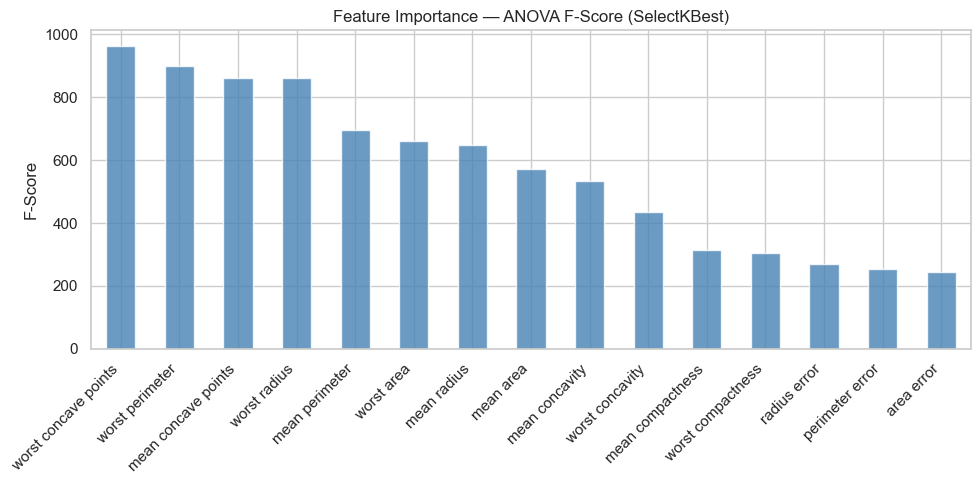

In [7]:
data = load_breast_cancer()
X, y = pd.DataFrame(data.data, columns=data.feature_names), data.target

# --- VarianceThreshold ---
vt = VarianceThreshold(threshold=0.1)
X_vt = vt.fit_transform(X)
print(f"VarianceThreshold: {X.shape[1]} → {X_vt.shape[1]} features kept")

# --- SelectKBest (ANOVA F-test) ---
kbest = SelectKBest(score_func=f_classif, k=10)
kbest.fit(X, y)
scores = pd.Series(kbest.scores_, index=data.feature_names).sort_values(ascending=False)
print(f"\nTop 10 features by ANOVA F-score:")
for feat, score in scores.head(10).items():
    print(f"  {feat:<35}: {score:>8.1f}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
scores.head(15).plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Feature Importance — ANOVA F-Score (SelectKBest)')
ax.set_ylabel('F-Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
# --- RFE: Recursive Feature Elimination ---
# Trains a model, drops the weakest feature, repeats — keeps only the most useful k features
rfe = RFE(estimator=LogisticRegression(max_iter=1000), n_features_to_select=10)
rfe.fit(X, y)

rfe_selected = pd.Series(rfe.support_, index=data.feature_names)
print("RFE selected features:")
for feat in rfe_selected[rfe_selected].index:
    print(f"  ✓ {feat}")

/Users/anishupreti2002icloud.com/Desktop/Learning/relearning-concepts/myenv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/anishupreti2002icloud.com/Desktop/Learning/relearning-concepts/myenv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).


RFE selected features:
  ✓ mean radius
  ✓ mean compactness
  ✓ mean concavity
  ✓ texture error
  ✓ worst radius
  ✓ worst smoothness
  ✓ worst compactness
  ✓ worst concavity
  ✓ worst concave points
  ✓ worst symmetry


## PCA (Principal Component Analysis)

A technique that **reduces the number of features** while keeping as much useful information as possible.

---

### The Core Idea

Instead of keeping the original features, PCA creates **new features** (called components) that are combinations of the originals — ordered by how much variance (information) they capture.

```
Original features: age, salary, years_experience, education_level
                        ↓ PCA
New components:   PC1 (captures 70% of variance)
                  PC2 (captures 20% of variance)
                  PC3 (captures 8%  of variance)
                  PC4 (captures 2%  of variance)

→ Drop PC4, keep 98% of the information with only 3 features
```

### What PCA Actually Does

1. Finds the direction in the data where variance is highest → **PC1**
2. Finds the next best direction, perpendicular to PC1 → **PC2**
3. Repeats until it has as many components as original features
4. You pick how many to keep

---

### When to Use It

- Too many features and training is slow
- Features are highly correlated (multicollinearity) — PCA merges them
- You want to visualize high-dimensional data in 2D or 3D

---

### The Tradeoff

The new components are **not interpretable** — PC1 doesn't mean anything in the real world, it's a mathematical mix of all original features. PCA is great for prediction but not when you need to explain *why* the model made a decision.

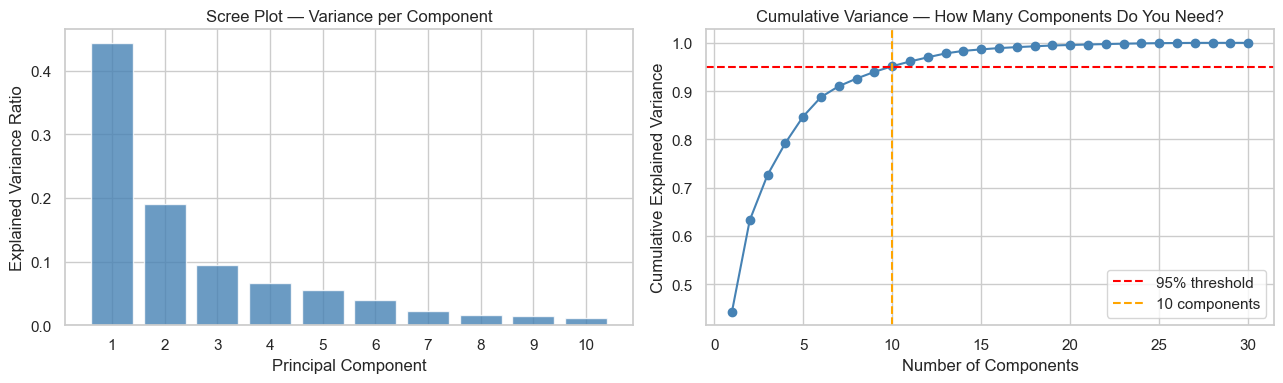

Original: 30 features
PCA for 95% variance: 10 components
Dimension reduction: 20 features removed, keeping 95% of information


In [9]:
# Scale first, then PCA (PCA is variance-based — unscaled features dominate)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_95 = np.argmax(cumulative_variance >= 0.95) + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Scree plot
ax1.bar(range(1, 11), pca.explained_variance_ratio_[:10], color='steelblue', alpha=0.8)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Scree Plot — Variance per Component')
ax1.set_xticks(range(1, 11))

# Cumulative variance
ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'o-', color='steelblue')
ax2.axhline(0.95, color='red', linestyle='--', label='95% threshold')
ax2.axvline(n_95, color='orange', linestyle='--', label=f'{n_95} components')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative Variance — How Many Components Do You Need?')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Original: {X.shape[1]} features")
print(f"PCA for 95% variance: {n_95} components")
print(f"Dimension reduction: {X.shape[1] - n_95} features removed, keeping 95% of information")

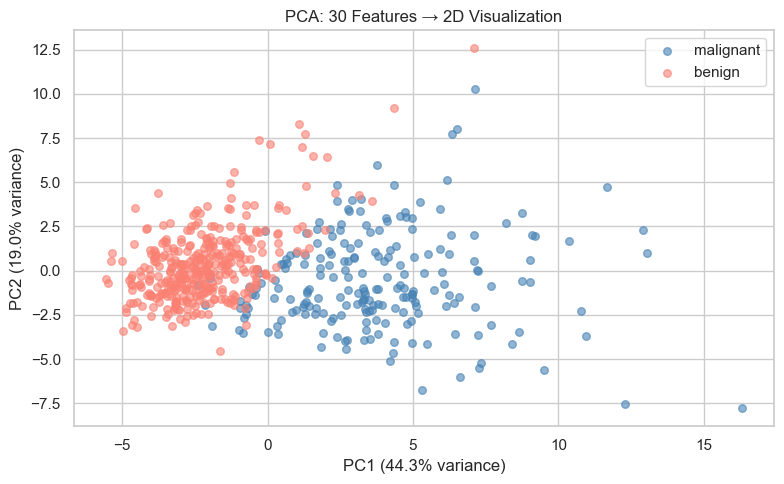

Even 2 components separate the classes clearly — the original 30 features are highly correlated.


In [10]:
# Visualize classes in 2D using first 2 PCA components
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue', 'salmon']
for cls, color, label in zip([0, 1], colors, data.target_names):
    mask = y == cls
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, alpha=0.6, s=30, label=label)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('PCA: 30 Features → 2D Visualization')
ax.legend()
plt.tight_layout()
plt.show()
print("Even 2 components separate the classes clearly — the original 30 features are highly correlated.")

## Feature Importance — Tree-Based Ranking

Tree models (Random Forest, Gradient Boosting) compute a built-in importance score for each feature based on how much it **reduces impurity** across all splits.

---

### How It Works

Every time a tree splits on a feature, it measures how much that split cleaned up the data (reduced impurity). These gains are averaged across all trees and all splits — that's the importance score.

```python
model.fit(X_train, y_train)

importances = model.feature_importances_
# [0.32, 0.18, 0.01, 0.24, 0.25]
# higher = feature was more useful for making splits
```

---

### The Caveat — High Cardinality Bias

Built-in importance scores can be **biased toward features with many unique values**.

A feature like `customer_id` (thousands of unique values) gets more opportunities to split than `gender` (2 values) — so it can appear important even when it's not.

```
customer_id  → 10,000 unique values → many split opportunities → inflated score
gender       → 2 unique values      → few split opportunities  → deflated score
```

---

### Permutation Importance — More Reliable

Instead of tracking splits, it asks: *"what happens to model accuracy if I randomly shuffle this feature?"*

- If shuffling `age` destroys accuracy → `age` is important
- If shuffling `customer_id` changes nothing → it was never useful

```python
from sklearn.inspection import permutation_importance

result = permutation_importance(model, X_test, y_test, n_repeats=10)
result.importances_mean  # average accuracy drop per feature
```

> Always use permutation importance when you have high-cardinality features or want a more trustworthy ranking. Run it on the **test set**, not train.

---

### Quick Comparison

| Method | How it works | Watch out for |
|--------|-------------|---------------|
| Built-in (`feature_importances_`) | Impurity reduction across splits | Biased toward high-cardinality features |
| Permutation importance | Accuracy drop when feature is shuffled | Slower, but more reliable |

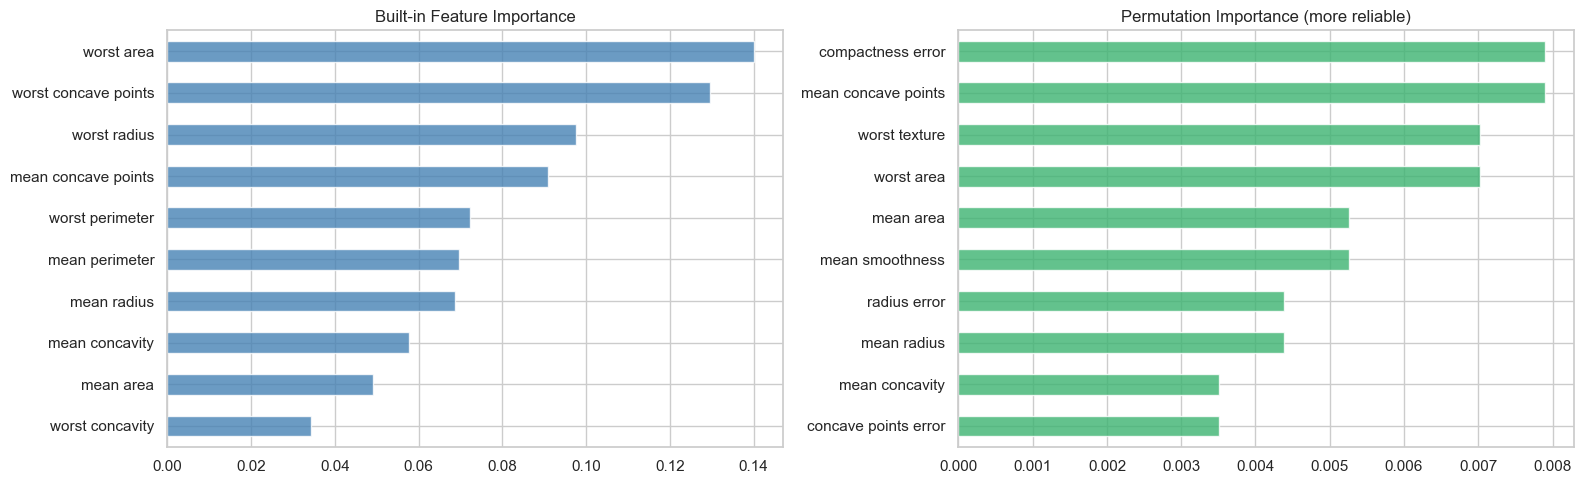

Top 5 features (built-in): ['worst area', 'worst concave points', 'worst radius', 'mean concave points', 'worst perimeter']
Top 5 features (permutation): ['compactness error', 'mean concave points', 'worst texture', 'worst area', 'mean area']


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Built-in importance
built_in = pd.Series(rf.feature_importances_, index=data.feature_names).sort_values(ascending=False)

# Permutation importance (shuffle each feature, see how much accuracy drops)
perm_imp = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)
perm = pd.Series(perm_imp.importances_mean, index=data.feature_names).sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

built_in.head(10).plot(kind='barh', ax=ax1, color='steelblue', alpha=0.8)
ax1.set_title('Built-in Feature Importance')
ax1.invert_yaxis()

perm.head(10).plot(kind='barh', ax=ax2, color='mediumseagreen', alpha=0.8)
ax2.set_title('Permutation Importance (more reliable)')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

print("Top 5 features (built-in):", list(built_in.head(5).index))
print("Top 5 features (permutation):", list(perm.head(5).index))

## 8. Putting It All Together — Full Preprocessing Pipeline

This is the pattern you'll use in every real ML project:
```
Raw data
  → ColumnTransformer (different processing per column type)
      → numeric: impute missing → scale
      → nominal: impute missing → one-hot encode
      → ordinal: impute missing → ordinal encode
  → Feature Selection (optional)
  → Model
```

In [14]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# convert to plain Python strings — data.feature_names returns numpy.str_ which ColumnTransformer rejects
numeric_features = [str(f) for f in data.feature_names]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    # SelectKBest removed from here — ColumnTransformer doesn't pass y to inner steps
    # so SelectKBest (which needs y to compute F-scores) would crash
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
])

for name, model in [
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ('Random Forest',       RandomForestClassifier(n_estimators=100, random_state=42)),
    ('Gradient Boosting',   GradientBoostingClassifier(n_estimators=100, random_state=42)),
]:
    pipe = Pipeline(steps=[
        ('prep',     preprocessor),
        ('selector', SelectKBest(f_classif, k=15)),  # SelectKBest goes HERE — main pipeline passes y correctly
        ('model',    model)
    ])
    pipe.fit(X_train, y_train)
    print(f"{name:<25}: {pipe.score(X_test, y_test):.4f}")


Logistic Regression      : 0.9649
Random Forest            : 0.9561
Gradient Boosting        : 0.9386


## Practice

**1.** You have a feature `neighborhood` with 200 unique values. You encode it with OneHotEncoder. What problem does this create and what would you use instead?  

=> => OneHotEncoding a feature with 200 unique values creates 200 new columns. This adds noise, slows training, and can cause overfitting — too many columns relative to the actual signal. The fix is Target Encoding — replace each neighborhood with the mean of the target variable for that neighborhood. 200 unique values become 1 numeric column that carries real predictive signal.  

**2.** A colleague scales the entire dataset before splitting into train/test. What exactly did they leak, and how would you explain why this inflates test accuracy?  

=> I think you meant fit, in case of fit if we fit on whole dataset, then the model will learn the pattern and statistics of test data too(data leakage), and the result will be optimistic(better than actual).

**3.** PCA on your dataset shows that 3 components capture 99% of variance, but the original data has 50 features. Would you always use PCA in this case? What's the main thing you lose?  

=> Using PCA here would obviously decrease the number of columns so we will have less features to work with. But it comes with a tradeoff and that is we cannot interpret the PCA features like we can do for the original ones.

**4.** Your Random Forest's built-in importance shows `user_id` as the top feature. Why is this a red flag, and what should you use instead?  

=> In case of built-in feature importance, it highly depends on the number of unique values(high cardinality), as the user id is all unique it shows very high importance. To fix this, what we can do is use permutation importance to shuffle and check the accuracy again on test data. If the accuracy does not drop or change much, then we cna drop the user_id column because it is not useful for unseen data.

---

## Key Takeaways

- **Pipeline = reproducible, leak-free preprocessing** — fit only on train, apply to test
- **ColumnTransformer** applies different transforms to different column groups in one step
- **StandardScaler** for normally distributed features, **RobustScaler** when outliers exist, **MinMaxScaler** for neural networks / bounded features
- **OneHot** for nominal, **Ordinal** for ordered, never LabelEncoder on input features
- **SelectKBest** for quick feature filtering, **RFE** when you have a target model in mind
- **PCA** compresses correlated features — always scale first, use when dimensionality is high
- **Permutation importance** is more reliable than built-in tree importance for feature ranking